In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ***Introduction***

Hotels collect a lot of data from their customers during the booking process. This data can help hotels understand customer behavior and improve their services. In this project, we want to build a machine learning model to predict whether a hotel booking will be canceled or not.

By using this model, hotels can better prepare for guest arrivals, avoid empty rooms, and plan their resources more effectively.

# ***Business Understanding***

When guests cancel their bookings, it can cause **problems** for the hotel, such as:
* Losing money because rooms are left empty
* Wasting resources like staff, food, and cleaning services
* Messing up planning, especially during busy seasons

This project will help the hotel **predict which bookings are likely to be canceled.** The data includes things like:
* Number of adults and children
* Type of room and meal plan
* How early the booking was made
* Whether the guest has canceled before
* If the guest made special requests

With this information, **the hotel can:**
* Plan better for room availability
* Contact guests early to confirm bookings
* Improve customer service and reduce cancellations

This prediction model can help the ***hotel work more efficiently and serve customers better.***

# ***Data Description***

1. Booking_ID = Pengenal unik dari tiap pemesanan
2. no_of_adults = Jumlah orang dewasa
3. no_of_children = Jumlah anak kecil
4. no_of_weekend_nights = Jumlah malam akhir pekan (Sabtu atau Minggu) tamu menginap atau
memesan untuk menginap di hotel
5. no_of_week_nights = Jumlah malam dalam seminggu (Senin hingga Jumat) tamu menginap atau
memesan untuk menginap di hotel
6. type_of_meal_plan = Jenis paket makanan yang dipesan oleh pelanggan
7. required_car_parking_space = Apakah pelanggan membutuhkan tempat parkir mobil? (0 - Tidak, 1-
Ya)
8. room_type_reserved = Jenis kamar yang dipesan oleh pelanggan. Nilai-nilai tersebut dienkripsi oleh
INN Hotels
9. lead_time = Jumlah hari antara tanggal pemesanan dan tanggal kedatangan
10. arrival_year = Tahun tanggal kedatangan
11. arrival_month = Bulan tanggal kedatangan
12. arrival_date = Tanggal kedatangan
13. market_segment_type = Penunjukan segmen pasar
14. repeated_guest = Apakah pelanggan tersebut merupakan tamu yang pernah melakukan booking dan
juga menginap? (0 - Tidak, 1- Ya)
15. no_of_previous_cancellations = Jumlah pemesanan sebelumnya yang dibatalkan oleh pelanggan
sebelum pemesanan saat ini
16. no_of_previous_bookings_not_canceled = Jumlah pemesanan sebelumnya yang tidak dibatalkan
oleh pelanggan sebelum pemesanan saat ini
17. avg_price_per_room = Harga rata-rata per hari pemesanan; harga kamar bersifat dinamis. (dalam
euro)
18. no_of_special_requests = Jumlah total permintaan khusus yang dibuat oleh pelanggan (misalnya
lantai yang tinggi, pemandangan dari kamar, dan lain-lain.)
19. booking_status (target variable) = Flag yang menunjukkan apakah pemesanan dibatalkan atau tidak.

In [155]:
# read dataset
df = pd.read_csv("Dataset_B_hotel.csv")
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0.0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0.0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0.0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0.0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0.0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


# ***Exploratory Data Analysis***

## ***Check Duplicated Data***

In [158]:
df.duplicated().sum()

0

Although no duplicate data was found in the current dataset, it's essential to understand the impact and reasoning behind handling duplicates. If duplicated records are found in a dataset, usually we need to remove them using drop_duplicates(). Duplicate rows can lead to data leakage, biased training, or misleading insights, especially in classification problems like predicting booking cancellations.



## ***Inconsistent/Incorrect Data Types***

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     35368 non-null  object 
 6   required_car_parking_space            35005 non-null  float64
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In a nutshell here are things we need to do:
1. Drop Booking_ID
   * Because it is just a unique identifier and doesn’t help in prediction. So we will remove it.
2. Handling missing value
   * For type_of_meal_plan and required_car_parking_space, we will either drop or fill missing values depending on what's more appropriate.
   * For avg_price_per_room, we will fill the missing values with the median/mean, since it is a numerical column.
3. Convert categorical columns into numerical (encoding)
   * type_of_meal_plan
   * room_type_reserved
   * market_segment_type
4. Some of the variable which don't have to encode
   * required_car_parking_space and repeated_guest already have numeric values (0 or 1), so we can use them directly as categorical features.

In [163]:
# checking unique value for all categorical variable
df['type_of_meal_plan'].value_counts()

type_of_meal_plan
Meal Plan 1     27157
Not Selected     4986
Meal Plan 2      3220
Meal Plan 3         5
Name: count, dtype: int64

In [164]:
df['room_type_reserved'].value_counts()

room_type_reserved
Room_Type 1    28130
Room_Type 4     6057
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64

In [165]:
df['market_segment_type'].value_counts()

market_segment_type
Online           23214
Offline          10528
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64

In [166]:
df['booking_status'].value_counts()

booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64

From the value_counts above, we can see there are no inconsistent values, so we don't need to clean or fix anything here.

In [168]:
df['required_car_parking_space'].value_counts()

required_car_parking_space
0.0    33910
1.0     1095
Name: count, dtype: int64

For `required_car_parking_space`, it's captured as a float, so we can convert it to int (optional) just to ensure consistency and avoid potential issues during processing.

In [170]:
df.shape # 36275 rows 18 columns

(36275, 19)

`df.shape` shows the dataset has 36,275 rows and 18 columns, it means we have 36,275 entries and 18 features to work with.

First before we do the next step, we need to check the distribution of the data briefly using histogram.

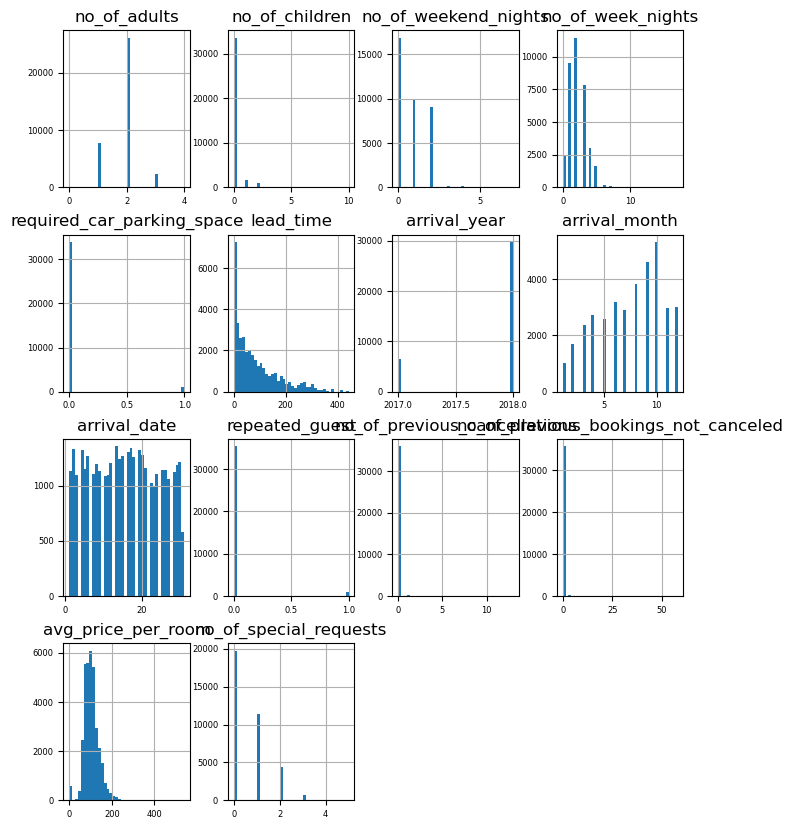

In [173]:
df.hist(figsize=(8, 10), bins=40, xlabelsize=6, ylabelsize=6);

At a glance, we can see that many variables contain outliers that is indicated by the skewness in their distributions.

## ***Missing Values***

In [176]:
df.isna().sum()

Booking_ID                                 0
no_of_adults                               0
no_of_children                             0
no_of_weekend_nights                       0
no_of_week_nights                          0
type_of_meal_plan                        907
required_car_parking_space              1270
room_type_reserved                         0
lead_time                                  0
arrival_year                               0
arrival_month                              0
arrival_date                               0
market_segment_type                        0
repeated_guest                             0
no_of_previous_cancellations               0
no_of_previous_bookings_not_canceled       0
avg_price_per_room                      1632
no_of_special_requests                     0
booking_status                             0
dtype: int64

Missing value found:
1. type_of_meal_plan (categorical) = chage N/A to not_selected
2. required_car_parking_space (num)
3. avg_price_per_room (num)

Since the `required_parking_space` is actually a categorical value, it would be invalid for doing the computation using mean. So we would do the computation using mode/median (both will have the same rest of 0), instead of do the computation using mean.

In [179]:
df['required_car_parking_space'].value_counts()

required_car_parking_space
0.0    33910
1.0     1095
Name: count, dtype: int64

In [180]:
df['required_car_parking_space'].fillna(df['required_car_parking_space'].median(), inplace=True)

C:\Users\acer\AppData\Local\Temp\ipykernel_4528\1291307764.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['required_car_parking_space'].fillna(df['required_car_parking_space'].median(), inplace=True)


In [181]:
# also covert to int as we discuss before
df['required_car_parking_space'] = df['required_car_parking_space'].astype(int)

For `avg_price_per_room` we know it is numerical so then before do the imputation we need to check whether the data has outliers (skewed) or not

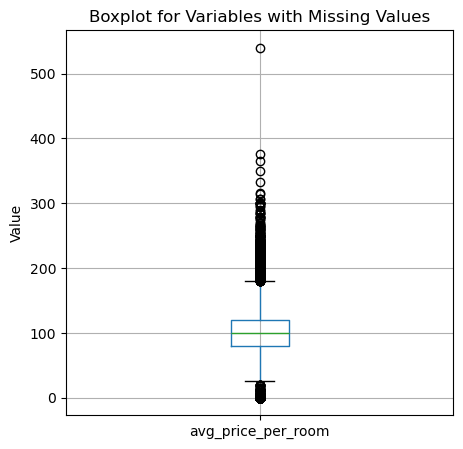

In [183]:
# looking for outliers
missing = df.boxplot(column=['avg_price_per_room'], figsize=(5, 5))
plt.title("Boxplot for Variables with Missing Values")
plt.ylabel("Value")
plt.show()

As we can see above, there are a lot of outliers, so we use the median instead of the mean because the median is less affected by extreme values and gives a better central tendency in such cases.

In [185]:
df['avg_price_per_room'].describe()

count    34643.000000
mean       103.447208
std         35.158417
min          0.000000
25%         80.300000
50%         99.450000
75%        120.275000
max        540.000000
Name: avg_price_per_room, dtype: float64

It is confirmed, because as we can see, 75% of the values are below 120.28, but the maximum value reaches 540, indicating the presence of outliers that skew the distribution.

In [187]:
# we do the imputation using median
df['avg_price_per_room'].fillna(df['avg_price_per_room'].median(), inplace=True)

C:\Users\acer\AppData\Local\Temp\ipykernel_4528\1567468498.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['avg_price_per_room'].fillna(df['avg_price_per_room'].median(), inplace=True)


For `type_of_meal_plan` (categorical) we need to do the computation using mode.

In [189]:
df['type_of_meal_plan'].value_counts()

type_of_meal_plan
Meal Plan 1     27157
Not Selected     4986
Meal Plan 2      3220
Meal Plan 3         5
Name: count, dtype: int64

In [190]:
df['type_of_meal_plan'].mode()

0    Meal Plan 1
Name: type_of_meal_plan, dtype: object

In [191]:
# replacing NA to with mode
df['type_of_meal_plan'].fillna('Meal Plan 1', inplace=True)
# df['type_of_meal_plan'].fillna(df['type_of_meal_plan'].mode(), inplace=True)

C:\Users\acer\AppData\Local\Temp\ipykernel_4528\3371324987.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['type_of_meal_plan'].fillna('Meal Plan 1', inplace=True)


In [192]:
df.isna().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [215]:
# drop Booking_ID because it's just unique variable
df.drop('Booking_ID', axis=1, inplace=True)

## ***Distribution***

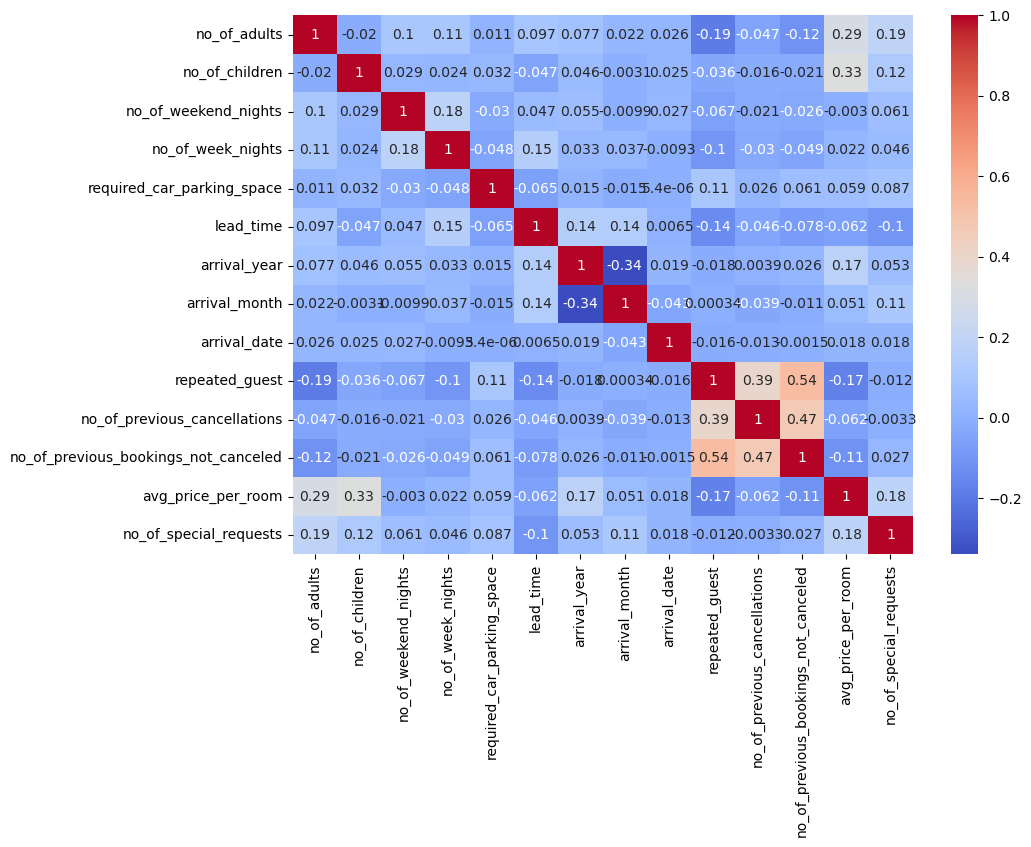

In [217]:
plt.figure(figsize=(10,7))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm');

**Positive Correlation**
* `no_of_previous_bookings_not_canceled` and `avg_price_per_room` (0.54): This suggests that customers who have previously made bookings that were not canceled tend to book more expensive rooms. This might imply that repeat customers or those with a history of consistent bookings may have higher expectations or are more willing to spend on premium rooms. This could be valuable for targeting higher-spending customers or setting pricing strategies.
* Repeated Guest with `no_of_previous_bookings_not_canceled` (0.47) and `avg_price_per_room` (0.39): The strong correlation with the number of previous bookings not canceled indicates that repeated guests are likely to have a history of successful stays, contributing to both loyalty and a higher likelihood of choosing more expensive rooms. This could signal a potential area for personalized marketing to repeat guests, offering incentives to book at higher prices or to increase the likelihood of return visits.

**Moderate Correlation**
* `no_of_children` and `no_of_adults` (0.33): This positive correlation reflects the expected relationship between family bookings—if the number of children increases, it’s likely that the number of adults will also rise. This is useful for setting family-friendly pricing and room configurations, as well as promoting packages that cater to family needs (ex: rooms with multiple beds or family-oriented amenities).
* `lead_time` with `arrival_year` (-0.22) and `no_of_previous_cancellations` (-0.21): A moderate negative correlation with arrival_year suggests that customers may book further in advance during certain years, which could be influenced by factors such as holiday seasons, special events, or economic conditions. The negative correlation with no_of_previous_cancellations indicates that guests with a history of cancellations tend to book closer to their stay, which might reflect uncertainty or flexibility in their plans. Understanding this could help the hotel adjust its cancellation policies or offer incentives to reduce cancellations.

<Axes: xlabel='no_of_previous_bookings_not_canceled', ylabel='avg_price_per_room'>

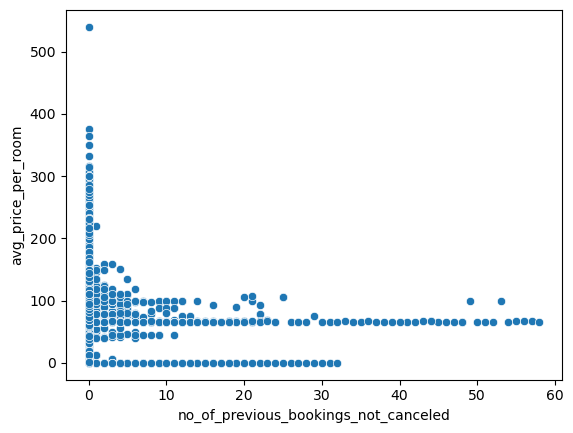

In [222]:
sns.scatterplot(data=df, x='no_of_previous_bookings_not_canceled', y='avg_price_per_room')

**Possible business insight**
* Target low-price rooms: Since many prices are now closer to the median (low), focusing on budget customers is still a good idea.
* Target high-price rooms: The few high-priced rooms are even rarer now, so consider targeting these customers with special offers. But maybe this could due to some hotels might over VIP room or presidential suite.

<Axes: xlabel='arrival_year', ylabel='lead_time'>

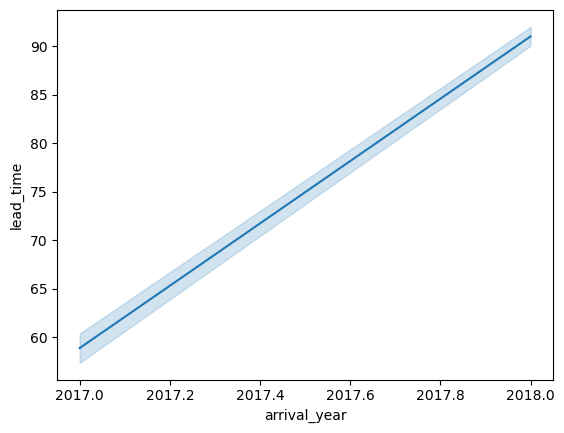

In [225]:
sns.lineplot(data=df, x='arrival_year', y='lead_time')

As the years go by, most people seem to prefer booking earlier, meaning they have a longer lead time (the number of days between booking and check-in).
* People are planning their trips further in advance.
* They may be trying to get better deals or ensure availability.
* It could also show increased confidence in travel plans, especially if cancellation rates are low.
  
More guests are booking their stays well ahead of time as time goes on.

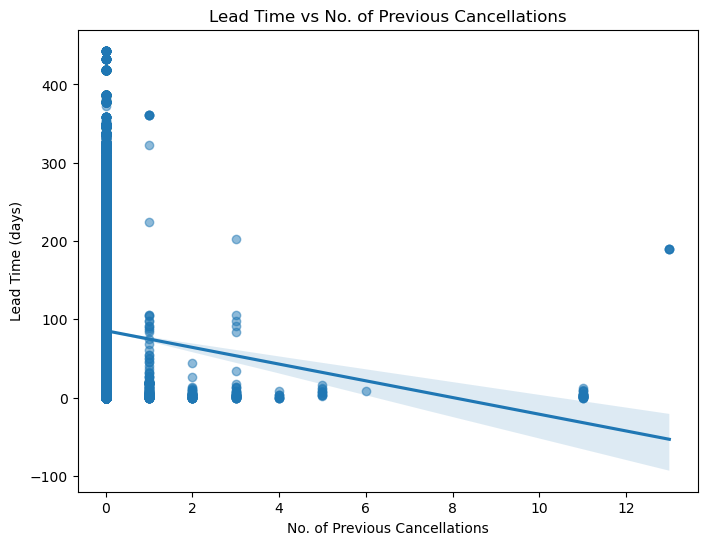

In [235]:
plt.figure(figsize=(8, 6))
sns.regplot(x='no_of_previous_cancellations', y='lead_time', data=df, scatter_kws={'alpha':0.5})
plt.title('Lead Time vs No. of Previous Cancellations')
plt.xlabel('No. of Previous Cancellations')
plt.ylabel('Lead Time (days)')
plt.show()

Guests with more past cancellations tend to book closer to their check-in date (shorter lead time). This could mean they are:
* More uncertain about their travel plans.
* Less committed or more spontaneous.
* Possibly making last-minute decisions that are more prone to changes.

This pattern suggests that guests who book early are generally more reliable and less likely to cancel. On the other hand, those who book late may do so with lower confidence in their plans.

## ***Handling Outliers***

As we saw before, there are a lot of outliers varying across the variables, so we need to handle them because outliers can distort statistical analyses, affect model performance, and lead to inaccurate predictions.

In [126]:
# make a list caled num for all numerical variable
num = []
for col in df.columns:
  if df[col].dtype == 'int64' or df[col].dtype == 'float64':
    num.append(col)

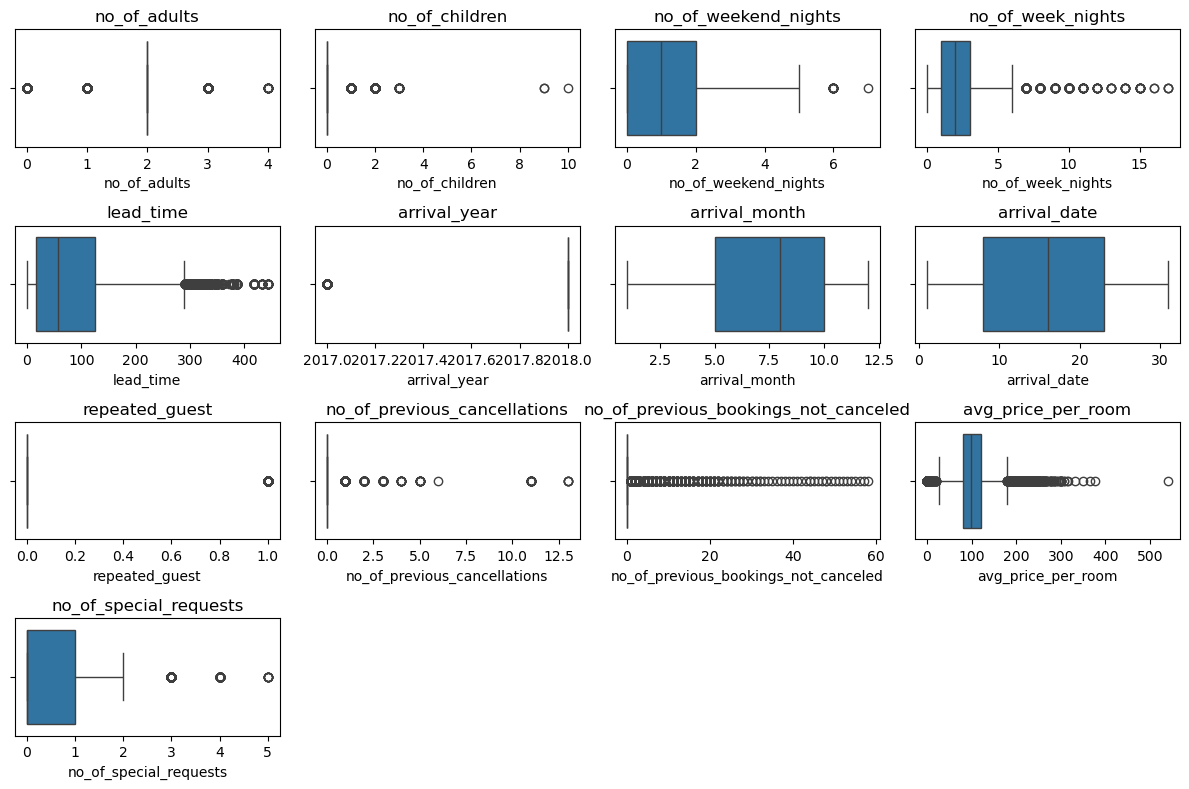

In [128]:
import math

plt.figure(figsize=(12, 8))
n = len(num)  
cols = 4    
rows = math.ceil(n / cols)  

for i, col in enumerate(num, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(data=df, x=col)
    plt.title(f"{col}")

plt.tight_layout()
plt.show()

Then we remove those outliers using the IQR method by applying the lower and upper bounds, replacing values outside the bounds with the corresponding boundary values. This ensures the data stays within a reasonable range and reduces the impact of extreme outliers.

In [130]:
numerical_cols = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                  'lead_time', 'avg_price_per_room', 'no_of_previous_cancellations',
                  'no_of_previous_bookings_not_canceled', 'no_of_special_requests']

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df[numerical_cols] = df[numerical_cols].apply(lambda x: np.where(x < lower_bound[x.name], lower_bound[x.name], x))
df[numerical_cols] = df[numerical_cols].apply(lambda x: np.where(x > upper_bound[x.name], upper_bound[x.name], x))

# ***Data Splitting***

In [439]:
input = df.drop('booking_status', axis=1)
output = df['booking_status']

Now we split the dataset into 70% for training and 30% for testing

In [440]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(input, output, test_size = 0.3, random_state = 42)

In [441]:
print('train data: ', x_train.shape)
print('test data: ', x_test.shape)

train data:  (25392, 17)
test data:  (10883, 17)


# ***Encoding***

Previously we say `type_of_meal_plan`, `room_type_reserved`, and `market_segment_type` are still in categorical value. So we need to encode them into numerical values so that machine learning models can understand and process them.

Here we use OneHot Encoding because the categorical variables have no natural order, and OneHot Encoding converts each category into a separate binary column, allowing the model to treat them fairly without assuming any ranking or priority.

In [443]:
from sklearn.preprocessing import OneHotEncoder
nom_cols = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# train
ohe_encoder.fit(x_train[nom_cols])
train_encoded = ohe_encoder.transform(x_train[nom_cols])
train_encoded_df = pd.DataFrame(train_encoded, columns=ohe_encoder.get_feature_names_out(nom_cols))
train_encoded_df.index = x_train.index
x_train = pd.concat([x_train.drop(nom_cols, axis=1), train_encoded_df], axis=1)

# test
test_encoded = ohe_encoder.transform(x_test[nom_cols])
test_encoded_df = pd.DataFrame(test_encoded, columns=ohe_encoder.get_feature_names_out(nom_cols))
test_encoded_df.index = x_test.index
x_test = pd.concat([x_test.drop(nom_cols, axis=1), test_encoded_df], axis=1)

In [444]:
x_train.head() # checking to make sure

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
29580,2.0,0.0,1.0,3.0,0,200.0,2018,8,29,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6325,2.0,0.0,1.0,3.0,0,79.0,2018,3,24,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
33899,2.0,0.0,1.0,4.0,0,78.0,2018,4,6,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
720,2.0,0.0,2.0,0.0,0,61.0,2017,10,4,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22120,2.0,0.0,0.0,4.0,0,201.0,2018,11,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Then we need to encode the y variabel (booking status) because it previously also categorical value (cancelled and not cancelled). We use label encoder because it can efficiently converts them into binary numeric values (0 and 1), which is suitable for classification models.

In [445]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

Because for arrival_year there is only 2017 & 2018 i will do label encoding for them

In [447]:
x_train['arrival_year'].value_counts()

arrival_year
2018    20808
2017     4584
Name: count, dtype: int64

In [448]:
x_train['arrival_year']  = le.fit_transform(x_train['arrival_year'])
x_test['arrival_year']  = le.transform(x_test['arrival_year'])

In [449]:
x_train['arrival_year'].value_counts()

arrival_year
1    20808
0     4584
Name: count, dtype: int64

# ***Scaling***

**Do we actually need to scale the data?**

For models like Random Forest and XGBoost, feature scaling is generally not necessary. This is because both are tree-based algorithms, which work by learning decision rules based on threshold splits rather than calculating distances or gradients.

But I decided to use RobustScaler because it uses the median and interquartile range (IQR) instead of the mean and standard deviation. This makes it less sensitive to outliers, previously we found so many extreme value, using RobustScaling the features will be scaled more appropriately.

In [453]:
from sklearn.preprocessing import RobustScaler 
robust = RobustScaler()
x_train = robust.fit_transform(x_train)
x_test = robust.transform(x_test)

# ***Build Model***

In [456]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [457]:
# i put the models in loop to save times and to reduce repetition
# comparing the model before finetuning
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extreme Gradient Boosting": XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
}

for name, model in models.items():
    print(f"~~~~~~~~~~~~~~~~~~ {name} ~~~~~~~~~~~~~~~~~~")
    model = model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy}")
    print(classification_report(y_test, y_pred, target_names=['Canceled', 'Not_Canceled']))
    print("\n")

~~~~~~~~~~~~~~~~~~ Random Forest ~~~~~~~~~~~~~~~~~~
Random Forest Accuracy: 0.9002113387852614
              precision    recall  f1-score   support

    Canceled       0.88      0.81      0.84      3607
Not_Canceled       0.91      0.95      0.93      7276

    accuracy                           0.90     10883
   macro avg       0.89      0.88      0.88     10883
weighted avg       0.90      0.90      0.90     10883



~~~~~~~~~~~~~~~~~~ Extreme Gradient Boosting ~~~~~~~~~~~~~~~~~~
Extreme Gradient Boosting Accuracy: 0.8872553523844529
              precision    recall  f1-score   support

    Canceled       0.86      0.79      0.82      3607
Not_Canceled       0.90      0.94      0.92      7276

    accuracy                           0.89     10883
   macro avg       0.88      0.86      0.87     10883
weighted avg       0.89      0.89      0.89     10883





**Random Forest (Accuracy: 90%)**
Precision:
* For "Canceled" bookings: 88% of the predicted cancellations were correct.
* For "Not Canceled" bookings: 91% of the predicted non-cancellations were correct.

Recall:
* For "Canceled" bookings: The model correctly identified 81% of actual cancellations.
* For "Not Canceled" bookings: The model correctly identified 95% of actual non-cancellations.

F1-Score:
* The balance between precision and recall is higher for "Not Canceled" (93%) compared to "Canceled" (84%).

Accuracy:
* Overall, the Random Forest model achieved an accuracy of 90%, indicating that the model is making the correct prediction for 90% of the cases.

**Extreme Gradient Boosting (XGBoost) (Accuracy: 88.7%)**
Precision:
* For "Canceled" bookings: 86% of the predicted cancellations were correct.
* For "Not Canceled" bookings: 90% of the predicted non-cancellations were correct.

Recall:
* For "Canceled" bookings: The model correctly identified 79% of actual cancellations.
* For "Not Canceled" bookings: The model correctly identified 94% of actual non-cancellations.

F1-Score:
* Similar to Random Forest, the "Not Canceled" class has a higher F1 score (92%) compared to "Canceled" (82%).

Accuracy:
* XGBoost achieved an accuracy of 88.7%, which is slightly lower than Random Forest.

***Comparison and Interpretation:***
1. Accuracy: Random Forest is slightly better (90%) than XGBoost (88.7%), but both models perform well.
2. Precision and Recall for "Not Canceled": Both models perform well in predicting the "Not Canceled" class with high precision (91%+), indicating that the models are very good at identifying bookings that are not canceled.
3. Precision and Recall for "Canceled": Random Forest does slightly better in precision for "Canceled" bookings (88% vs. 86%), but both models struggle a bit more in recalling cancellations, especially XGBoost (79% recall). This means that both models miss some cancellations, which could be problematic if minimizing false negatives (missed cancellations) is important.
4. Balanced F1-Score: The F1 scores for "Not Canceled" are very good, but the "Canceled" F1 scores are lower, suggesting that improving the model's recall for cancellations could benefit performance.



In [458]:
# hyperparameter tuning
param_grids = {
    "Random Forest": {
        "n_estimators": [50, 100, 200, 300],
        "max_depth": [None, 5, 10, 20, 30],
        "min_samples_split": [2, 3, 5, 10],
        'max_features': ['sqrt', 'log2', None, 0.8]
    },
    "Extreme Gradient Boosting": {
        'n_estimators': [100, 200, 300, 400],
        'max_depth': [3, 5, 6, 10],
        'learning_rate': [0.01, 0.1, 0.2, 0.3],
        'min_child_weight': [1, 3, 5, 7]
    }
}

**Random Forest**
1. n_estimators: The number of trees in the forest.
2. max_depth: The maximum depth of each tree.
3. min_samples_split: The minimum number of samples required to split an internal node.
4. max_features: The number of features to consider when looking for the best split.
   * 'sqrt': Uses the square root of the total number of features (default for classification).
   * 'log2': Uses the logarithm (base 2) of the total number of features.
   * None: Considers all features.
   * 0.8: Uses 80% of the features, which can help prevent overfitting.

**Extreme Gradient Boosting (XGBoost)**
1. n_estimators: The number of boosting rounds (trees in the ensemble).
2. max_depth: The maximum depth of the individual trees.
3. learning_rate: The step size used in each boosting round.
4. min_child_weight: The minimum sum of instance weight (hessian) needed in a child

In [459]:
from sklearn.model_selection import GridSearchCV

# tune each model
best_models = {}
for name, model in models.items():
    print(f"Tuning {name}...")
    grid_search = GridSearchCV(
        estimator = model,
        param_grid = param_grids[name],
        scoring = "accuracy",
        cv = 5,  # 5-fold cross-validation
        n_jobs = -1  # Use all processors
    )

    grid_search.fit(x_train, y_train)
    best_models[name] = grid_search.best_estimator_
    print(f"Best Parameters for {name}: {grid_search.best_params_}")
    print(f"Best Cross-Validation Accuracy for {name}: {grid_search.best_score_}\n")

Tuning Random Forest...
Best Parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 3, 'n_estimators': 100}
Best Cross-Validation Accuracy for Random Forest: 0.8934701274801033

Tuning Extreme Gradient Boosting...
Best Parameters for Extreme Gradient Boosting: {'learning_rate': 0.2, 'max_depth': 10, 'min_child_weight': 1, 'n_estimators': 100}
Best Cross-Validation Accuracy for Extreme Gradient Boosting: 0.8885079004970773



In [530]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

rf = RandomForestClassifier(random_state=42)  # You can choose any integer
rf.fit(x_train, y_train)
best_models["Random Forest"] = rf
rf_model = best_models["Random Forest"]
rf_pred = rf_model.predict(x_test)

# Metrics
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc = roc_auc_score(y_test, rf_model.predict_proba(x_test)[:,1])
report = classification_report(y_test, rf_pred, target_names=['Not_Canceled', 'Canceled'])

print(f"Random Forest:")
print(f"Accuracy = {rf_acc:.4f}")
print(f"F1 Score = {rf_f1:.4f}")
print(f"AUC = {rf_roc:.4f}")
print("Classification Report:\n", report)

Random Forest:
Accuracy = 0.9002
F1 Score = 0.9268
AUC = 0.9547
Classification Report:
               precision    recall  f1-score   support

Not_Canceled       0.88      0.81      0.84      3607
    Canceled       0.91      0.95      0.93      7276

    accuracy                           0.90     10883
   macro avg       0.89      0.88      0.88     10883
weighted avg       0.90      0.90      0.90     10883



**Interpretation:**
* Random Forest performs exceptionally well across the board, showing a perfect balance between precision and recall, particularly for the Canceled class, with an pretty high recall of 0.95. This suggests it is better at identifying canceled bookings without missing many, which is important for predicting cancellations accurately.
* The F1 score of 0.9268 indicates that the Random Forest model strikes an great balance between precision and recall, especially for both Canceled and Not_Canceled classes.
* The AUC of 0.9547 shows that Random Forest has a strong ability to differentiate between the two classes, with minimal risk of misclassifying bookings.

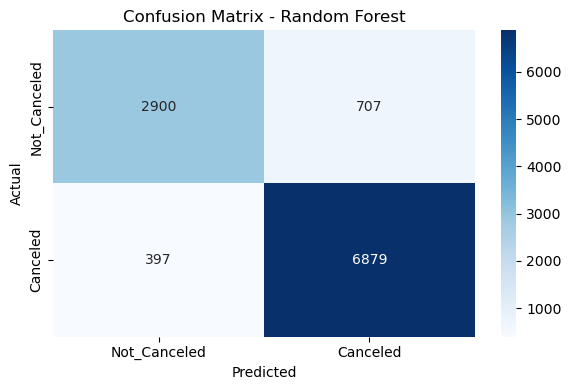

In [461]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Not_Canceled', 'Canceled'], yticklabels=['Not_Canceled', 'Canceled'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

1. True Positives (TP): 6879 bookings were correctly identified as Canceled. These are the cases where the model accurately predicted a cancellation.
2. True Negatives (TN): 2900 bookings were correctly identified as Not Canceled. These are the cases where the model correctly predicted that the booking wouldn’t be canceled.
3. False Positives (FP): 707 bookings were incorrectly predicted as Canceled when they were actually Not Canceled. This means the model falsely predicted cancellations for these bookings.

False Negatives (FN):

397 bookings were incorrectly predicted as Not Canceled when they were actually Canceled. These are the cases where the model failed to predict a cancellation.

Insights:
The model correctly predicted Not Canceled bookings 2900 times and Canceled bookings 6879 times, showing a high level of accuracy.

There are 707 false positives (bookings wrongly predicted as Canceled) and 397 false negatives (bookings wrongly predicted as Not Canceled). These show areas where the model could improve.

The model is more accurate at predicting Canceled bookings than Not Canceled bookings, as seen from the higher number of true positives compared to false negatives.

In [ ]:
confusion matrix random forest
not canceled 2900 707
canceled 397 6879

In [462]:
# Predictions
xgb_model = best_models["Extreme Gradient Boosting"]
xgb_pred = xgb_model.predict(x_test)

# Metrics
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc = roc_auc_score(y_test, xgb_model.predict_proba(x_test)[:,1])
xgb_report = classification_report(y_test, xgb_pred, target_names=['Not_Canceled', 'Canceled'])

print(f"Extreme Gradient Boosting:")
print(f"Accuracy = {xgb_acc:.4f}")
print(f"F1 Score = {xgb_f1:.4f}")
print(f"AUC = {xgb_roc:.4f}")
print("Classification Report:\n", xgb_report)

Extreme Gradient Boosting:
Accuracy = 0.8964
F1 Score = 0.9238
AUC = 0.9565
Classification Report:
               precision    recall  f1-score   support

Not_Canceled       0.87      0.81      0.84      3607
    Canceled       0.91      0.94      0.92      7276

    accuracy                           0.90     10883
   macro avg       0.89      0.87      0.88     10883
weighted avg       0.90      0.90      0.90     10883



**Interpretation:**
* XGBoost, while also performing well, shows slightly lower recall for the Canceled class (0.94) compared to Random Forest (0.95). This suggests that Random Forest is slightly better at catching canceled bookings, which is crucial for accurate prediction in this case.
* The AUC for XGBoost is slightly higher (0.9565), but the difference is minimal and does not outweigh the performance of Random Forest in terms of overall accuracy and recall.

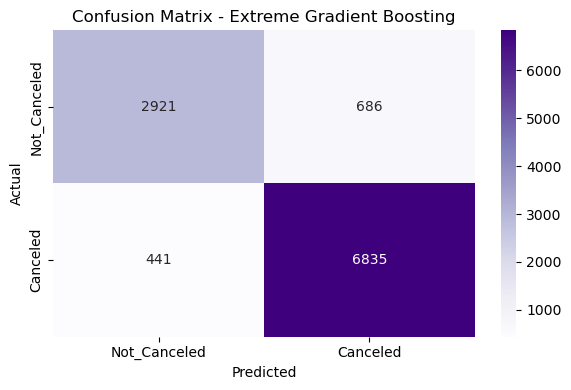

In [463]:
# Confusion Matrix
xgb_cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(xgb_cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=['Not_Canceled', 'Canceled'],
            yticklabels=['Not_Canceled', 'Canceled'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Extreme Gradient Boosting")
plt.tight_layout()
plt.show()

# ***Comparison***

After tuning both models, it is clear that **Random Forest** performs better than **XGBoost**, especially in predicting **Canceled** bookings. Even though both models are strong, **Random Forest** has a **slightly higher recall** for the **Canceled** class (0.95 compared to XGBoost's 0.94). This means that **Random Forest** is better at identifying bookings that are likely to be canceled, which is critical when trying to predict cancellations and take action early, like offering incentives to reduce cancellations.

Additionally, **Random Forest** has a **higher F1 score of 0.9268**, which shows it is more balanced between **precision** and **recall**. A higher F1 score means the model is making fewer mistakes when predicting both **canceled** and **not canceled** bookings. This is important because we want a model that doesn't miss too many cancellations but also doesn't falsely predict too many cancellations.

Even though **XGBoost** has a slightly higher **AUC (0.9565 compared to 0.9547)**, the difference is very small and does not significantly affect the overall performance. The **AUC** measures how well the model separates the two classes (Canceled and Not Canceled), and both models perform very well in this area. However, **Random Forest** still shines when it comes to being **more consistent and reliable** in predicting cancellations.

In summary, while **XGBoost** is a strong model, **Random Forest** offers a more reliable and balanced performance, especially in terms of predicting **Canceled** bookings accurately. Its higher **recall** and **F1 score** make it the better choice for the given task. Therefore, **Random Forest** is the better model overall for predicting hotel booking cancellations.

# ***Pickle File***

In [532]:
best_model = best_models["Random Forest"]

In [548]:
import pickle
with open('best_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

In [536]:
with open('best_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# just test
sample_pred = loaded_model.predict(x_test[:5])
print("Prediction Example:", sample_pred)

Prediction Example: [1 1 1 0 1]


In [550]:
import joblib
joblib.dump(best_model, 'best_model.pkl',compress=3)

['best_model.joblib']

# ***Presentation Link***

https://drive.google.com/drive/folders/1c5D2WYQag3JKNTUfk2XYvLfAEsNgiDaa?usp=sharing 